## 1 · Imports & Configuration

In [25]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, InputLayer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical, plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

ACCENT   = '#7C3AED'   #
ACCENT2  = '#06B6D4'  
RED      = '#EF4444'
GREEN    = '#22C55E'

print(f'TensorFlow {tf.__version__}  |  NumPy {np.__version__}')
print('GPU:', tf.config.list_physical_devices('GPU') or 'None – using CPU')

TensorFlow 2.19.1  |  NumPy 1.26.4
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [26]:
# ── Configuration ────────────────────────────────────────────────────────
DATA_DIR        = 'features'
SEQUENCE_LENGTH = 30
FEATURES_DIM    = 447
NUM_CLASSES     = 40
MODEL_SAVE_PATH = 'signlingo_v2_gru_4.h5'
RANDOM_STATE    = 42


## 2 · Data Loading & Exploration

Each **action** folder inside `features/` contains `.npy` files, one per recorded sequence.
Every sequence must have shape `(30, 447)` — 30 frames × 447 MediaPipe keypoints.

In [27]:
def load_data(data_dir):
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Directory '{data_dir}' not found.")

    actions = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])

    if len(actions) != NUM_CLASSES:
        print(f'⚠ Expected {NUM_CLASSES} classes, found {len(actions)}.')

    label_map = {label: num for num, label in enumerate(actions)}
    sequences, labels, skipped = [], [], 0

    for action in actions:
        action_path = os.path.join(data_dir, action)
        for seq_file in os.listdir(action_path):
            if not seq_file.endswith('.npy'):
                continue
            res = np.load(os.path.join(action_path, seq_file))
            if res.shape == (SEQUENCE_LENGTH, FEATURES_DIM):
                sequences.append(res)
                labels.append(label_map[action])
            else:
                skipped += 1

    X = np.array(sequences)
    y = to_categorical(labels, num_classes=len(actions)).astype(int)
    print(f'Loaded {X.shape[0]} sequences  |  Skipped {skipped} bad shapes')
    return X, y, actions, len(actions)


X, y, actions, num_classes = load_data(DATA_DIR)
print(f'X shape : {X.shape}   (samples × timesteps × features)')
print(f'y shape : {y.shape}   (samples × classes)')
print(f'Classes : {num_classes}')
print('Labels  :', actions)


Loaded 4573 sequences  |  Skipped 0 bad shapes
X shape : (4573, 30, 447)   (samples × timesteps × features)
y shape : (4573, 40)   (samples × classes)
Classes : 40
Labels  : ['Apa', 'Apa Kabar', 'Bagaimana', 'Baik', 'Belajar', 'Berapa', 'Berdiri', 'Bingung', 'Dia', 'Dimana', 'Duduk', 'Halo', 'Kalian', 'Kami', 'Kamu', 'Kapan', 'Kemana', 'Kita', 'Makan', 'Mandi', 'Marah', 'Melihat', 'Membaca', 'Menulis', 'Mereka', 'Minum', 'Pendek', 'Ramah', 'Sabar', 'Saya', 'Sedih', 'Selamat Malam', 'Selamat Pagi', 'Selamat Siang', 'Selamat Sore', 'Senang', 'Siapa', 'Terima Kasih', 'Tidur', 'Tinggi']


### 2.1 · Samples per Class

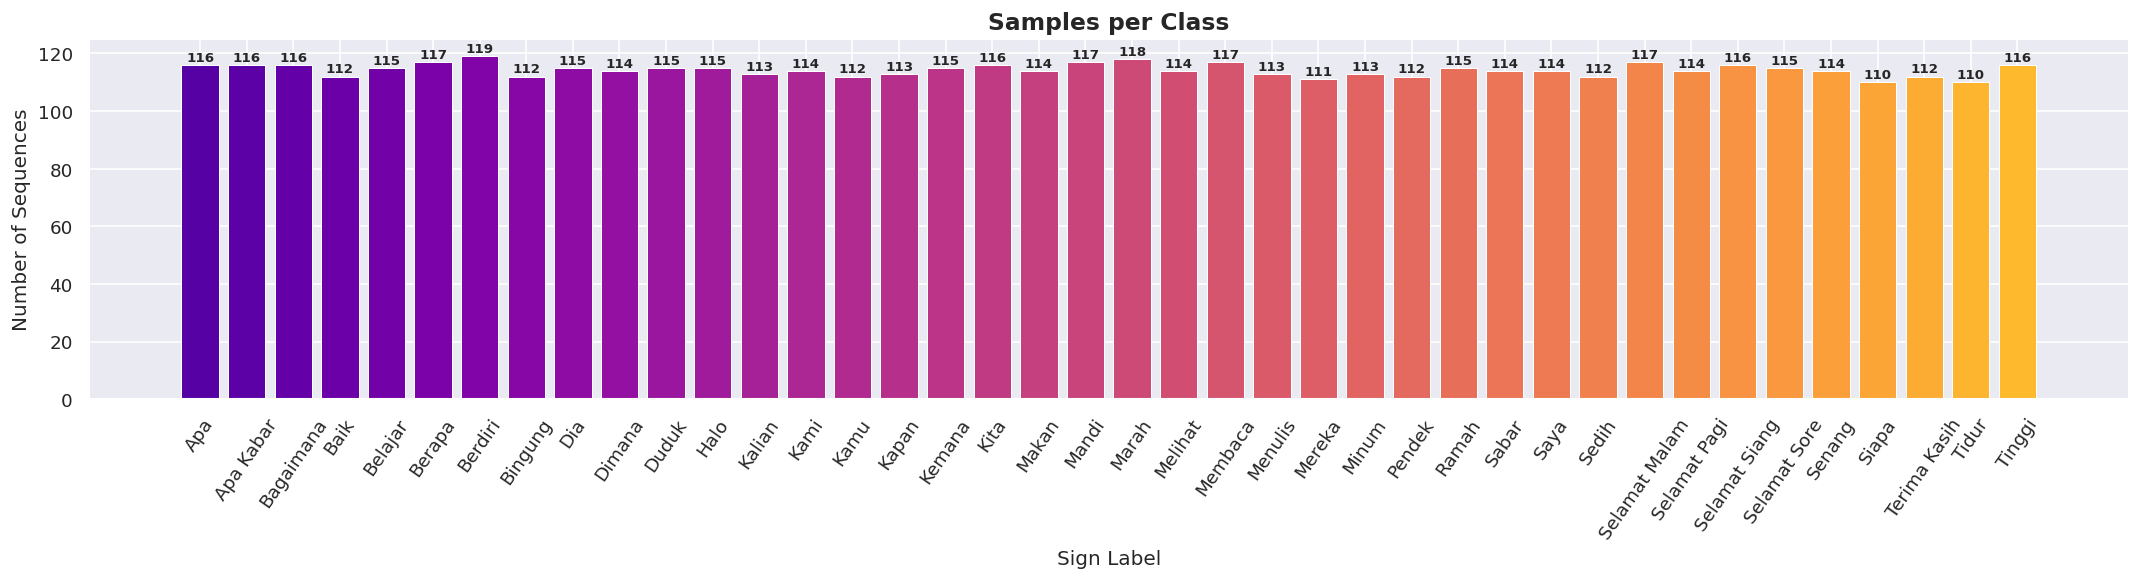

Min: 110  |  Max: 119  |  Mean: 114.3


In [28]:
y_int   = np.argmax(y, axis=1)
counts  = [np.sum(y_int == i) for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(max(12, num_classes * 0.45), 5))
bars = ax.bar(actions, counts,
              color=plt.cm.plasma(np.linspace(0.15, 0.85, num_classes)),
              edgecolor='white', linewidth=0.6)
ax.set_title('Samples per Class', fontweight='bold')
ax.set_xlabel('Sign Label')
ax.set_ylabel('Number of Sequences')
ax.tick_params(axis='x', rotation=55)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Min: {min(counts)}  |  Max: {max(counts)}  |  Mean: {np.mean(counts):.1f}')


In [29]:
# Make all the dataset sample uniform at 110
MAX_SAMPLES_PER_CLASS = 110
balanced_indices = []

# Convert one-hot labels back to integers to identify class groups
y_ints = np.argmax(y, axis=1)

for i in range(num_classes):
    # Get all indices belonging to this class
    class_indices = np.where(y_ints == i)[0]
    
    # Take up to 110 samples
    selected = class_indices[:MAX_SAMPLES_PER_CLASS]
    balanced_indices.extend(selected)

# Update X and y with the balanced subset
X = X[balanced_indices]
y = y[balanced_indices]

print(f"✅ Flattening complete.")
print(f"New X shape: {X.shape}")
print(f"New y shape: {y.shape}")

# Verify the count
unique, counts = np.unique(np.argmax(y, axis=1), return_counts=True)
print("Samples per class:", dict(zip(actions, counts)))


✅ Flattening complete.
New X shape: (4400, 30, 447)
New y shape: (4400, 40)
Samples per class: {'Apa': 110, 'Apa Kabar': 110, 'Bagaimana': 110, 'Baik': 110, 'Belajar': 110, 'Berapa': 110, 'Berdiri': 110, 'Bingung': 110, 'Dia': 110, 'Dimana': 110, 'Duduk': 110, 'Halo': 110, 'Kalian': 110, 'Kami': 110, 'Kamu': 110, 'Kapan': 110, 'Kemana': 110, 'Kita': 110, 'Makan': 110, 'Mandi': 110, 'Marah': 110, 'Melihat': 110, 'Membaca': 110, 'Menulis': 110, 'Mereka': 110, 'Minum': 110, 'Pendek': 110, 'Ramah': 110, 'Sabar': 110, 'Saya': 110, 'Sedih': 110, 'Selamat Malam': 110, 'Selamat Pagi': 110, 'Selamat Siang': 110, 'Selamat Sore': 110, 'Senang': 110, 'Siapa': 110, 'Terima Kasih': 110, 'Tidur': 110, 'Tinggi': 110}


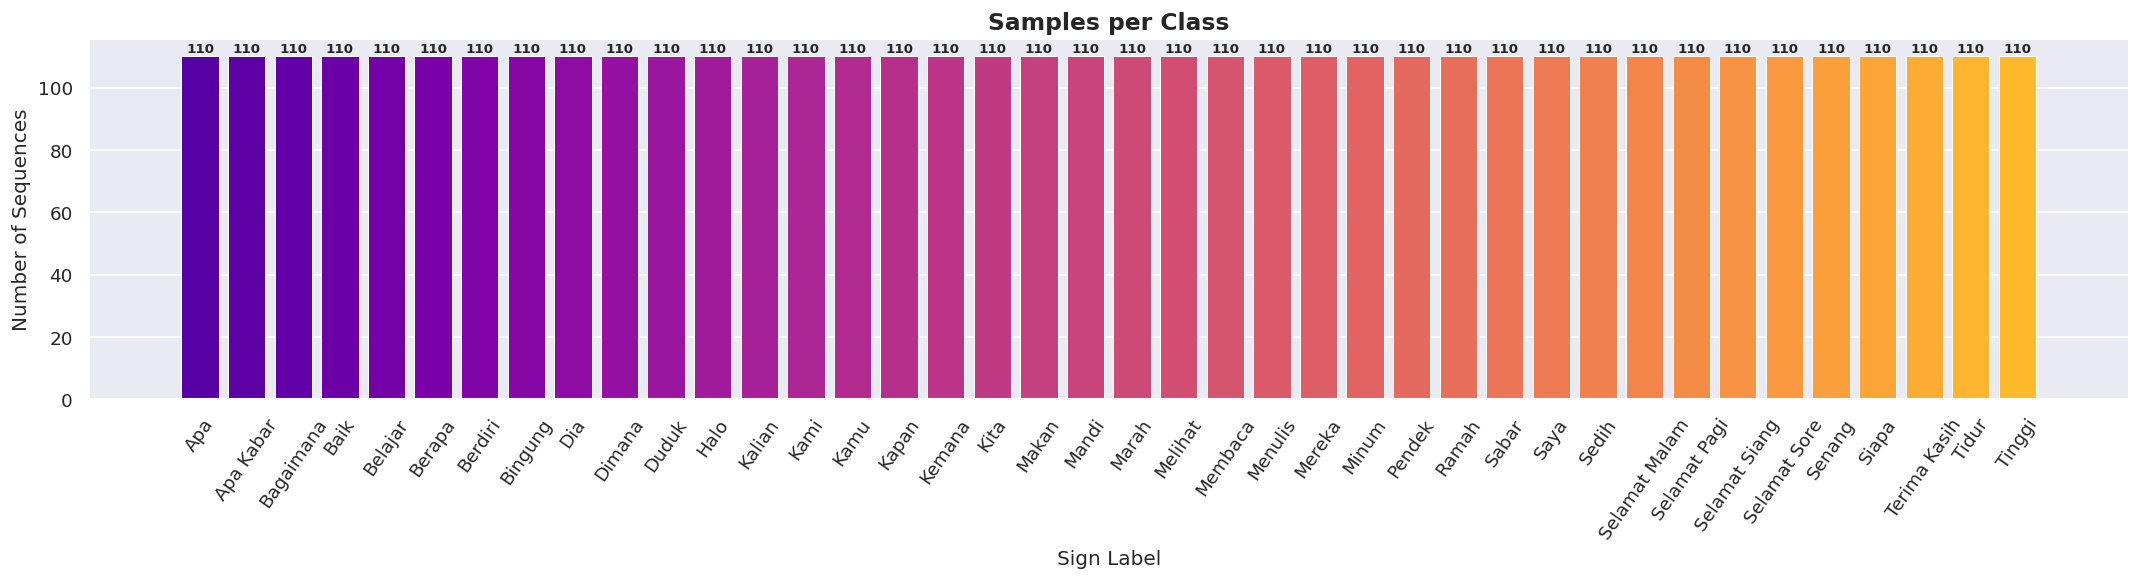

Min: 110  |  Max: 110  |  Mean: 110.0


In [30]:
y_int   = np.argmax(y, axis=1)
counts  = [np.sum(y_int == i) for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(max(12, num_classes * 0.45), 5))
bars = ax.bar(actions, counts,
              color=plt.cm.plasma(np.linspace(0.15, 0.85, num_classes)),
              edgecolor='white', linewidth=0.6)
ax.set_title('Samples per Class', fontweight='bold')
ax.set_xlabel('Sign Label')
ax.set_ylabel('Number of Sequences')
ax.tick_params(axis='x', rotation=55)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Min: {min(counts)}  |  Max: {max(counts)}  |  Mean: {np.mean(counts):.1f}')


## 3 · Train / Validation / Test Split

**80% train · 10% validation · 10% test** with stratified sampling to keep class balance.

In [31]:
# 80 / 20
try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
except ValueError:
    print('Falling back to non-stratified split (first stage).')
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_STATE)

# 10 / 10  (split the 20%)
try:
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)
except ValueError:
    print('Falling back to non-stratified split (second stage).')
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

print(f'Train : {X_train.shape[0]:>5} samples')
print(f'Val   : {X_val.shape[0]:>5} samples')
print(f'Test  : {X_test.shape[0]:>5} samples')


Train :  3520 samples
Val   :   440 samples
Test  :   440 samples


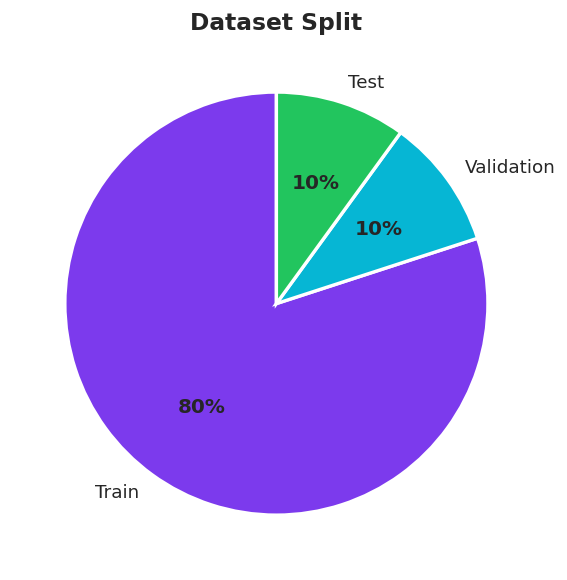

In [32]:
split_sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = ['Train', 'Validation', 'Test']
split_colors = [ACCENT, ACCENT2, GREEN]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    split_sizes,
    labels=split_labels,
    colors=split_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set(fontweight='bold', fontsize=12)
ax.set_title('Dataset Split', fontweight='bold')
plt.tight_layout()
plt.show()


In [33]:
def augment_sequence(data):
    """Applies a random combination of augmentations to a single sequence (30, 447)"""
    aug_data = data.copy()

    # 1. Gaussian Noise Injection (Jitter)
    # sigma=0.005 is subtle but effective for normalized landmarks
    noise = np.random.normal(0, 0.005, aug_data.shape)
    aug_data += noise

    # Reshape to (30, 149, 3) for spatial transforms (X, Y, Z triplets)
    aug_data = aug_data.reshape(30, -1, 3)

    # 2. Spatial Scaling (Uniformly scale by ±5%)
    scale = np.random.uniform(0.95, 1.05)
    aug_data *= scale

    # 3. Rotational Transformation (Minor rotation 3-5 degrees)
    angle = np.radians(np.random.uniform(3, 5) * np.random.choice([-1, 1]))
    c, s = np.cos(angle), np.sin(angle)
    # Rotation matrix for Z-axis (plane of the image)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
    aug_data = np.dot(aug_data, R)

    # Flatten back to original feature dimension (447)
    aug_data = aug_data.reshape(30, 447)

    # 4. Temporal Stretching (Systematically duplicate or omit frames ~10%)
    stretch = np.random.uniform(0.9, 1.1)
    new_len = int(30 * stretch)
    
    # Resample and interpolate back to 30 frames to maintain input shape
    stretched_data = np.zeros((30, 447))
    for f in range(447):
        # Interpolate the sequence over the new timeline
        stretched_data[:, f] = np.interp(
            np.linspace(0, 29, 30), 
            np.linspace(0, 29, new_len), 
            np.interp(np.linspace(0, 29, new_len), np.arange(30), aug_data[:, f])
        )

    return stretched_data

def apply_augmentation_pipeline(X, y, multiplier=2): # Multiplier is exchange able
    """Creates augmented copies of the training set"""
    X_aug_list, y_aug_list = [X], [y]
    
    print(f"Generating {X.shape[0] * multiplier} augmented samples...")
    for i in range(multiplier):
        X_new = np.array([augment_sequence(sample) for sample in X])
        X_aug_list.append(X_new)
        y_aug_list.append(y)
    
    X_final = np.concatenate(X_aug_list, axis=0)
    y_final = np.concatenate(y_aug_list, axis=0)
    
    # Shuffle the final augmented training set
    idx = np.random.permutation(len(X_final))
    return X_final[idx], y_final[idx]


In [34]:
# We only augment the training set. Val and Test must remain original for clean evaluation.
X_train_aug, y_train_aug = apply_augmentation_pipeline(X_train, y_train, multiplier=2)

print(f"Original Training Samples: {X_train.shape[0]}")
print(f"Augmented Training Samples: {X_train_aug.shape[0]}")

Generating 7040 augmented samples...
Original Training Samples: 3520
Augmented Training Samples: 10560


In [35]:
print(f'Train : {X_train_aug.shape[0]:>5} samples')
print(f'Val   : {X_val.shape[0]:>5} samples')
print(f'Test  : {X_test.shape[0]:>5} samples')

Train : 10560 samples
Val   :   440 samples
Test  :   440 samples


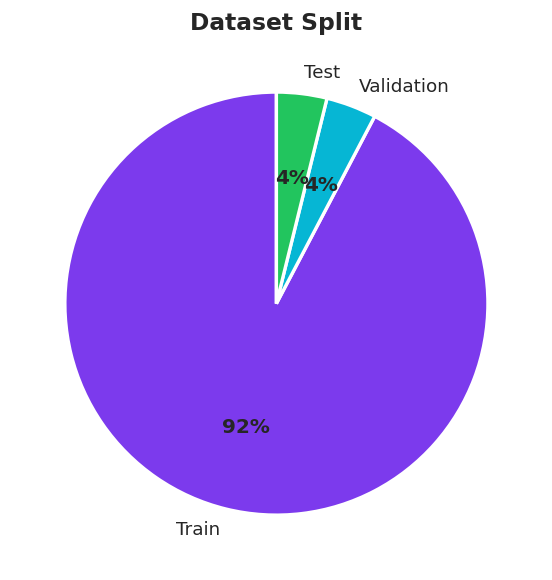

In [36]:
split_sizes = [X_train_aug.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = ['Train', 'Validation', 'Test']
split_colors = [ACCENT, ACCENT2, GREEN]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    split_sizes,
    labels=split_labels,
    colors=split_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set(fontweight='bold', fontsize=12)
ax.set_title('Dataset Split', fontweight='bold')
plt.tight_layout()
plt.show()


## 4 · Model Architecture

A two-layer **GRU** network with dropout regularisation, ending in a `softmax` classifier.

In [37]:
model = Sequential([
    InputLayer(input_shape=(SEQUENCE_LENGTH, FEATURES_DIM)),
    GRU(64, return_sequences=True, name='gru_1'),
    Dropout(0.2, name='dropout_1'),
    GRU(64, return_sequences=False, name='gru_2'),
    Dropout(0.2, name='dropout_2'),
    Dense(num_classes, activation='softmax', name='output'),
], name='SignLingo_GRU')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "SignLingo_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 30, 64)         │        98,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,056 (492.41 KB)

 Trainable params: 126,056 (492.41 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ── Visual architecture diagram ───────────────────────────────────────────
try:
    from tensorflow.keras.utils import plot_model
    plot_model(
        model,
        to_file='model_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        show_layer_activations=True,
        rankdir='TB',
        dpi=120,
    )
    from IPython.display import Image, display
    display(Image('model_architecture.png'))
except Exception as e:
    print(f'plot_model unavailable ({e}). Rendering text diagram instead.')

    # ── Text-based architecture visual ────────────────────────────────────
    layers_info = [
        ('Input',    f'({SEQUENCE_LENGTH}, {FEATURES_DIM})', ''),
        ('GRU-1',    '(30, 64)',                             'units=64, return_seq=True'),
        ('Dropout',  '(30, 64)',                             'rate=0.2'),
        ('GRU-2',    '(64,)',                                'units=64, return_seq=False'),
        ('Dropout',  '(64,)',                                'rate=0.2'),
        ('Dense',    f'({num_classes},)',                    'softmax'),
    ]

    colors = [ACCENT2, ACCENT, '#F59E0B', ACCENT, '#F59E0B', GREEN]
    fig, ax = plt.subplots(figsize=(8, len(layers_info) * 1.1))
    ax.set_xlim(0, 8)
    ax.set_ylim(-0.5, len(layers_info))
    ax.axis('off')

    for i, (name, shape, detail) in enumerate(reversed(layers_info)):
        y_pos = i
        color = colors[len(layers_info) - 1 - i]
        rect = mpatches.FancyBboxPatch(
            (1, y_pos - 0.38), 6, 0.76,
            boxstyle='round,pad=0.05',
            facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.92
        )
        ax.add_patch(rect)
        ax.text(2.1, y_pos, f'{name}', va='center', ha='left',
                fontsize=12, fontweight='bold', color='white')
        ax.text(5.0, y_pos + 0.15, shape, va='center', ha='left',
                fontsize=9, color='white', alpha=0.9)
        ax.text(5.0, y_pos - 0.18, detail, va='center', ha='left',
                fontsize=8, color='white', alpha=0.75)

        if i < len(layers_info) - 1:
            ax.annotate('', xy=(4, y_pos + 0.42), xytext=(4, y_pos + 0.58),
                        arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    ax.set_title('SignLingo GRU Architecture', fontweight='bold',
                 fontsize=15, color='white', pad=12)
    fig.patch.set_facecolor('#1E1B4B')
    ax.set_facecolor('#1E1B4B')
    plt.tight_layout()
    plt.show()


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


FileNotFoundError: No such file or directory: 'model_architecture.png'

FileNotFoundError: No such file or directory: 'model_architecture.png'

<IPython.core.display.Image object>

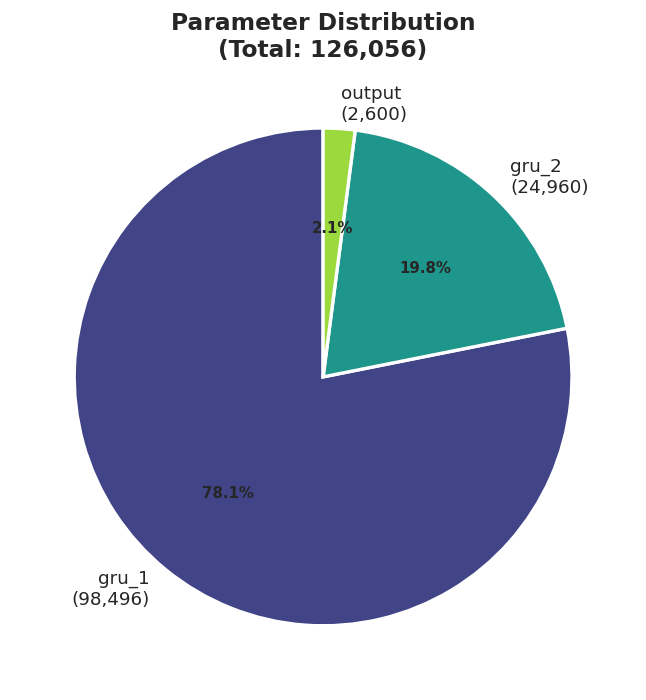

In [39]:
# ── Parameter breakdown pie chart ────────────────────────────────────────
param_data = {}
for layer in model.layers:
    p = layer.count_params()
    if p > 0:
        param_data[layer.name] = p

if param_data:
    fig, ax = plt.subplots(figsize=(6, 6))
    wedge_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(param_data)))
    wedges, texts, autotexts = ax.pie(
        list(param_data.values()),
        labels=[f'{n}\n({v:,})' for n, v in param_data.items()],
        colors=wedge_colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
    )
    for at in autotexts:
        at.set(fontsize=9, fontweight='bold')
    total = sum(param_data.values())
    ax.set_title(f'Parameter Distribution\n(Total: {total:,})', fontweight='bold')
    plt.tight_layout()
    plt.show()


## 5 · Callbacks & Training

| Callback | Setting |
|----------|---------|
| `EarlyStopping` | `patience=15`, restores best weights |
| `ReduceLROnPlateau` | `factor=0.5`, `patience=5`, `min_lr=1e-6` |
| `ModelCheckpoint` | saves best val_loss → `signlingo_v2_gru.h5` |


In [40]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)
checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH, monitor='val_loss',
    save_best_only=True, verbose=1
)

print('Starting training …')
history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=150,
    callbacks=[early_stopping, reduce_lr, checkpoint],
)
print('Training complete!')


Starting training …
Epoch 1/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.1847 - loss: 2.9875
Epoch 1: val_loss improved from None to 1.14384, saving model to signlingo_v2_gru_4.h5



Epoch 1: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3543 - loss: 2.2639 - val_accuracy: 0.6795 - val_loss: 1.1438 - learning_rate: 0.0010
Epoch 2/150
329/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7151 - loss: 1.0025
Epoch 2: val_loss improved from 1.14384 to 0.45535, saving model to signlingo_v2_gru_4.h5



Epoch 2: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7726 - loss: 0.8242 - val_accuracy: 0.8909 - val_loss: 0.4554 - learning_rate: 0.0010
Epoch 3/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8901 - loss: 0.4473
Epoch 3: val_loss improved from 0.45535 to 0.27374, saving model to signlingo_v2_gru_4.h5



Epoch 3: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9021 - loss: 0.3930 - val_accuracy: 0.9295 - val_loss: 0.2737 - learning_rate: 0.0010
Epoch 4/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9323 - loss: 0.2786
Epoch 4: val_loss improved from 0.27374 to 0.19090, saving model to signlingo_v2_gru_4.h5



Epoch 4: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9386 - loss: 0.2464 - val_accuracy: 0.9455 - val_loss: 0.1909 - learning_rate: 0.0010
Epoch 5/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9580 - loss: 0.1715
Epoch 5: val_loss improved from 0.19090 to 0.14863, saving model to signlingo_v2_gru_4.h5


...


Epoch 17: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9940 - loss: 0.0262 - val_accuracy: 0.9909 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 18/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9978 - loss: 0.0125
Epoch 18: val_loss did not improve from 0.02682
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9969 - loss: 0.0141 - val_accuracy: 0.9682 - val_loss: 0.0934 - learning_rate: 0.0010
Epoch 19/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9799 - loss: 0.0666
Epoch 19: val_loss did not improve from 0.02682
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9824 - loss: 0.0589 - val_accuracy: 0.9773 - val_loss: 0.0885 - learning_rate: 0.0010
Epoch 20/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9911 - loss: 0.0322
Epoch 20: val_loss did not improve from 0.02682
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9923 - loss: 0.0293 - val_accuracy: 0.9682 - val_


Epoch 31: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9932 - val_loss: 0.0256 - learning_rate: 2.5000e-04
Epoch 32/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 32: val_loss improved from 0.02557 to 0.02487, saving model to signlingo_v2_gru_4.h5



Epoch 32: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9932 - val_loss: 0.0249 - learning_rate: 2.5000e-04
Epoch 33/150
329/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9989 - loss: 0.0068
Epoch 33: val_loss did not improve from 0.02487
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9994 - loss: 0.0043 - val_accuracy: 0.9909 - val_loss: 0.0262 - learning_rate: 2.5000e-04
Epoch 34/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9998 - loss: 0.0019
Epoch 34: val_loss did not improve from 0.02487
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9999 - loss: 0.0016 - val_accuracy: 0.9909 - val_loss: 0.0270 - learning_rate: 2.5000e-04
Epoch 35/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9999 - loss: 0.0016
Epoch 35: val_loss did not improve from 0.02487
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0


Epoch 37: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9984 - loss: 0.0066 - val_accuracy: 0.9932 - val_loss: 0.0241 - learning_rate: 2.5000e-04
Epoch 38/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 38: val_loss improved from 0.02406 to 0.01038, saving model to signlingo_v2_gru_4.h5



Epoch 38: finished saving model to signlingo_v2_gru_4.h5
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9955 - val_loss: 0.0104 - learning_rate: 2.5000e-04
Epoch 39/150
328/330 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9995 - loss: 0.0026
Epoch 39: val_loss did not improve from 0.01038
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9991 - loss: 0.0034 - val_accuracy: 0.9932 - val_loss: 0.0154 - learning_rate: 2.5000e-04
Epoch 40/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9998 - loss: 0.0024
Epoch 40: val_loss did not improve from 0.01038
330/330 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9999 - loss: 0.0019 - val_accuracy: 0.9932 - val_loss: 0.0174 - learning_rate: 2.5000e-04
Epoch 41/150
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0010
Epoch 41: val_loss did not improve from 0.01038
330/330 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 1.0000 - loss: 9.6281e-04 - val_accurac

## 6 · Training Curves

Visualise **loss** and **accuracy** over every epoch for both train and validation sets.

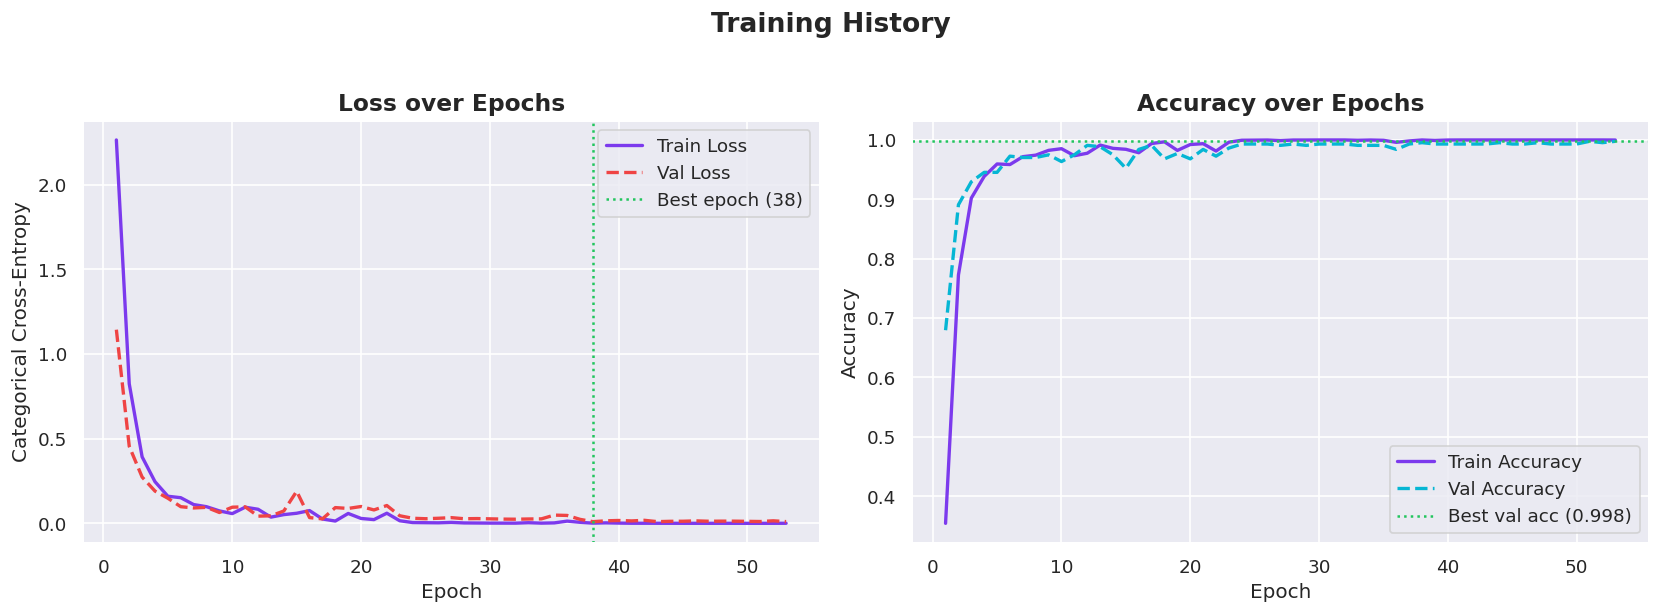

In [41]:
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_ran, hist['loss'],     color=ACCENT,  lw=2,   label='Train Loss')
ax.plot(epochs_ran, hist['val_loss'], color=RED,     lw=2,   label='Val Loss', linestyle='--')
best_epoch = int(np.argmin(hist['val_loss'])) + 1
ax.axvline(best_epoch, color=GREEN, lw=1.5, linestyle=':', label=f'Best epoch ({best_epoch})')
ax.set_title('Loss over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Categorical Cross-Entropy')
ax.legend()

# ── Accuracy ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_ran, hist['accuracy'],     color=ACCENT,  lw=2,   label='Train Accuracy')
ax.plot(epochs_ran, hist['val_accuracy'], color=ACCENT2, lw=2,   label='Val Accuracy',   linestyle='--')
best_val_acc = max(hist['val_accuracy'])
ax.axhline(best_val_acc, color=GREEN, lw=1.5, linestyle=':', label=f'Best val acc ({best_val_acc:.3f})')
ax.set_title('Accuracy over Epochs', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()

plt.suptitle('Training History', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [42]:
if 'lr' in hist:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(epochs_ran, hist['lr'], color=ACCENT2, lw=2)
    ax.set_title('Learning Rate Schedule', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_yscale('log')
    plt.tight_layout()
    plt.show()


## 7 · Final Evaluation on the Test Set

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy * 100:.2f}%')

# Predicted labels
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test, axis=1)

# Summary metrics
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'\nWeighted Precision : {prec:.4f}')
print(f'Weighted Recall    : {rec:.4f}')
print(f'Weighted F1 Score  : {f1:.4f}')


Test Loss     : 0.0688
Test Accuracy : 99.32%

Weighted Precision : 0.9938
Weighted Recall    : 0.9932
Weighted F1 Score  : 0.9932


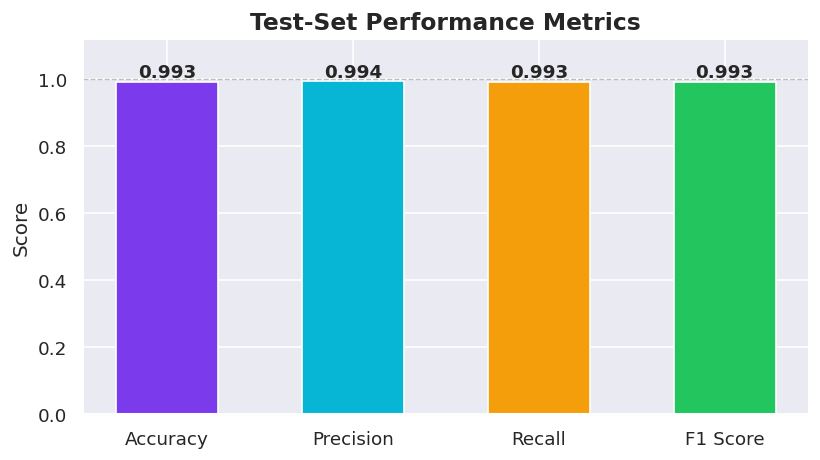

In [44]:
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
vals      = [test_accuracy, prec, rec, f1]
bar_colors= [ACCENT, ACCENT2, '#F59E0B', GREEN]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metrics, vals, color=bar_colors,
              edgecolor='white', linewidth=1, width=0.55)
ax.set_ylim(0, 1.12)
ax.axhline(1.0, color='grey', lw=0.8, linestyle='--', alpha=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Test-Set Performance Metrics', fontweight='bold')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


## 8 · Confusion Matrix

Rows = true class · Columns = predicted class.  
The diagonal shows correct predictions; off-diagonal cells show misclassifications.

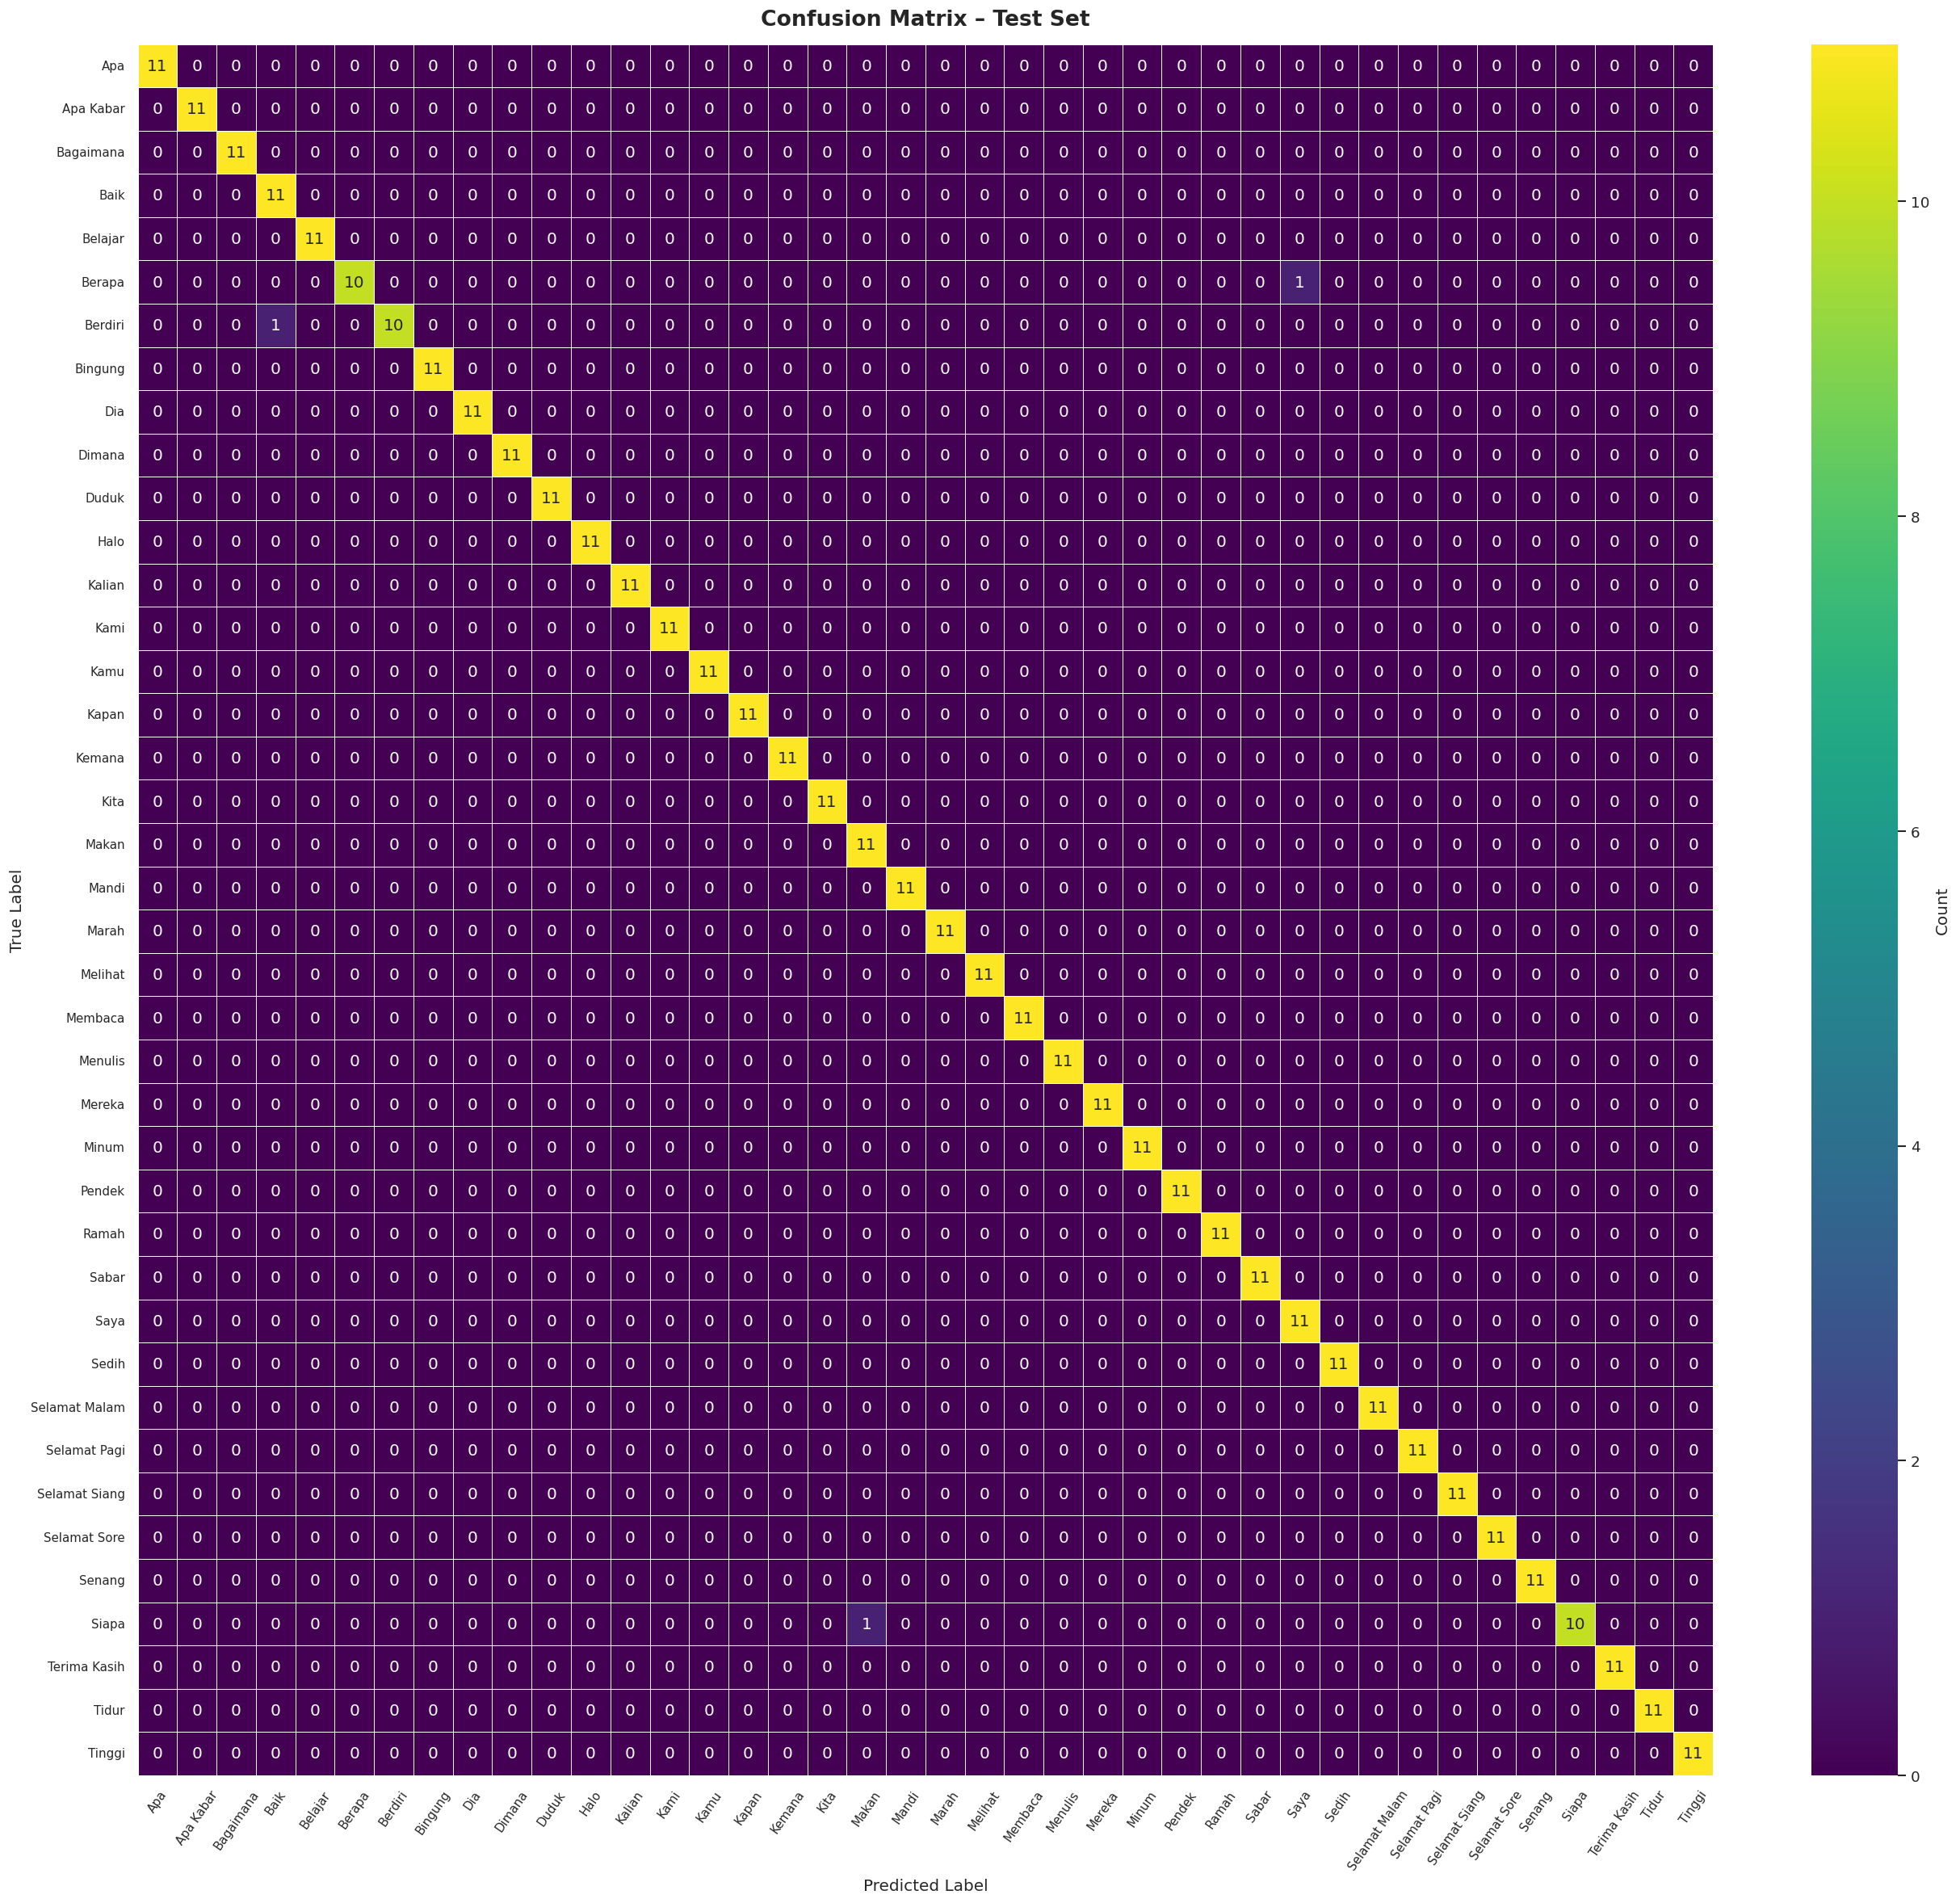

In [45]:
cm = confusion_matrix(y_true, y_pred)

fig_size = max(12, num_classes * 0.55)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=actions,
    yticklabels=actions,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Count'},
)
ax.set_title('Confusion Matrix – Test Set', fontweight='bold', fontsize=16, pad=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=55, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


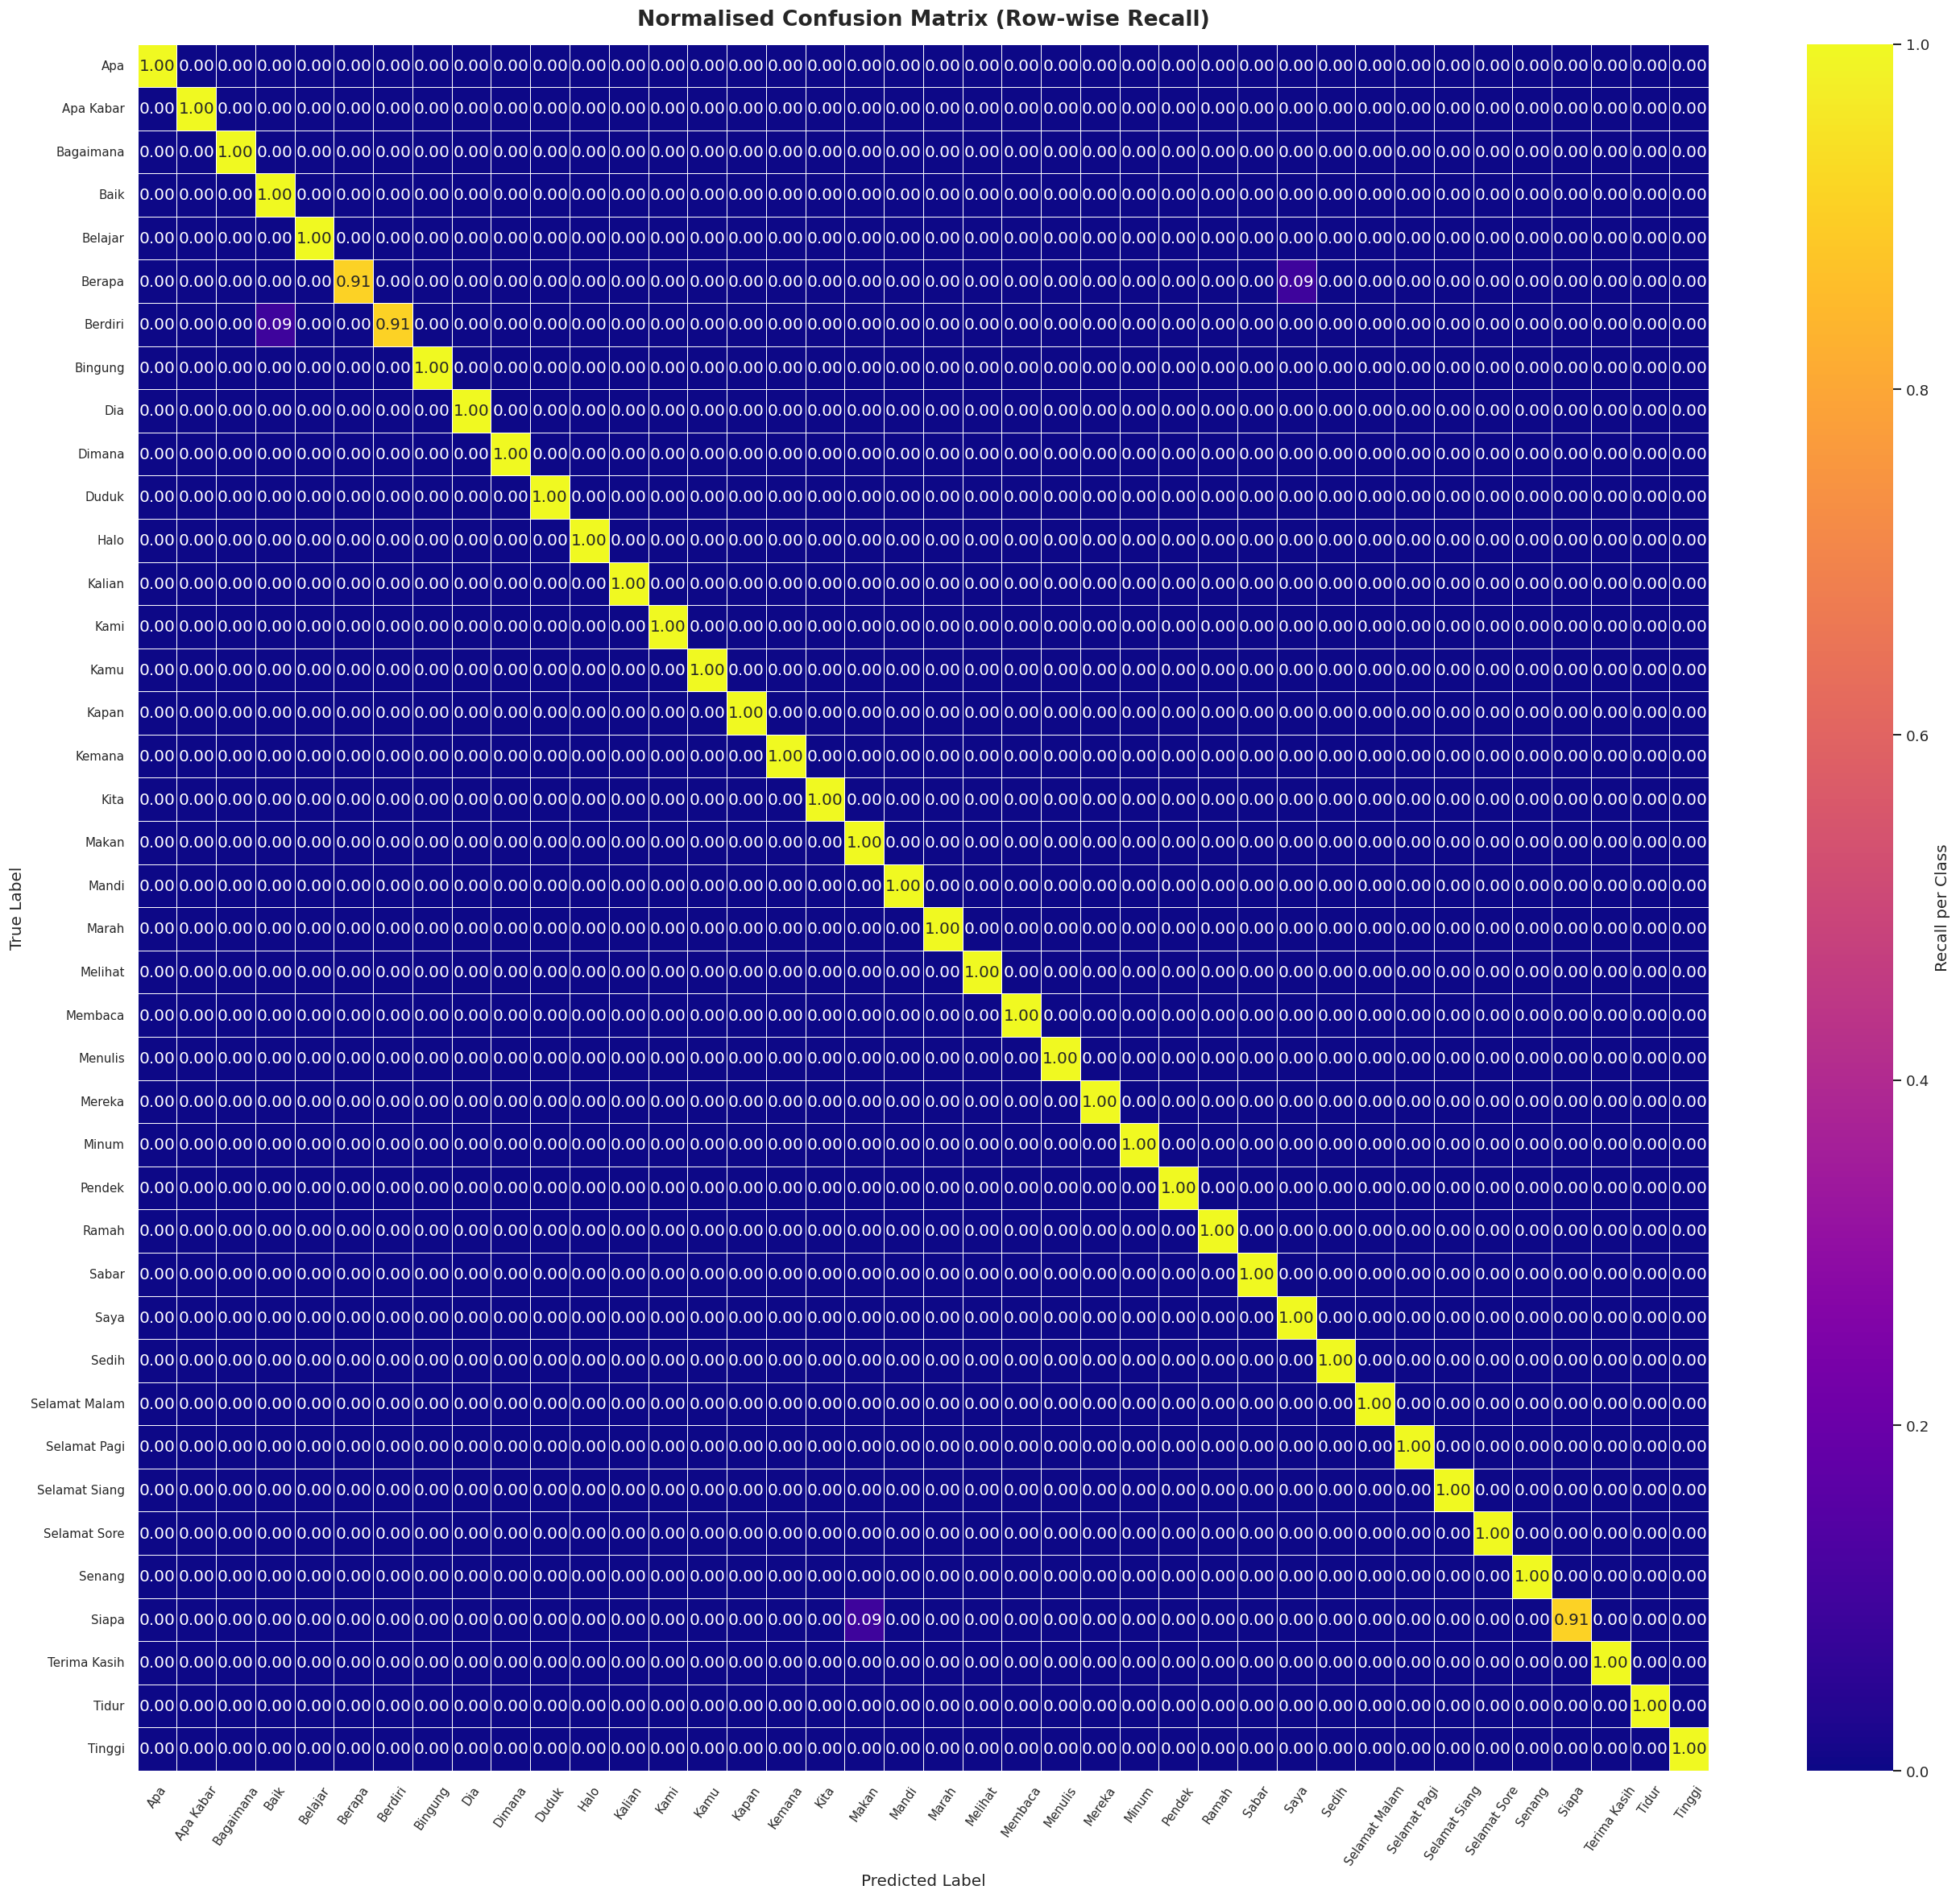

In [46]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.9))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='plasma',
    xticklabels=actions,
    yticklabels=actions,
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=1,
    ax=ax,
    cbar_kws={'label': 'Recall per Class'},
)
ax.set_title('Normalised Confusion Matrix (Row-wise Recall)', fontweight='bold', fontsize=16, pad=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=55, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()


## 9 · Per-Class Metrics

Detailed precision, recall, and F1 for each individual sign class.

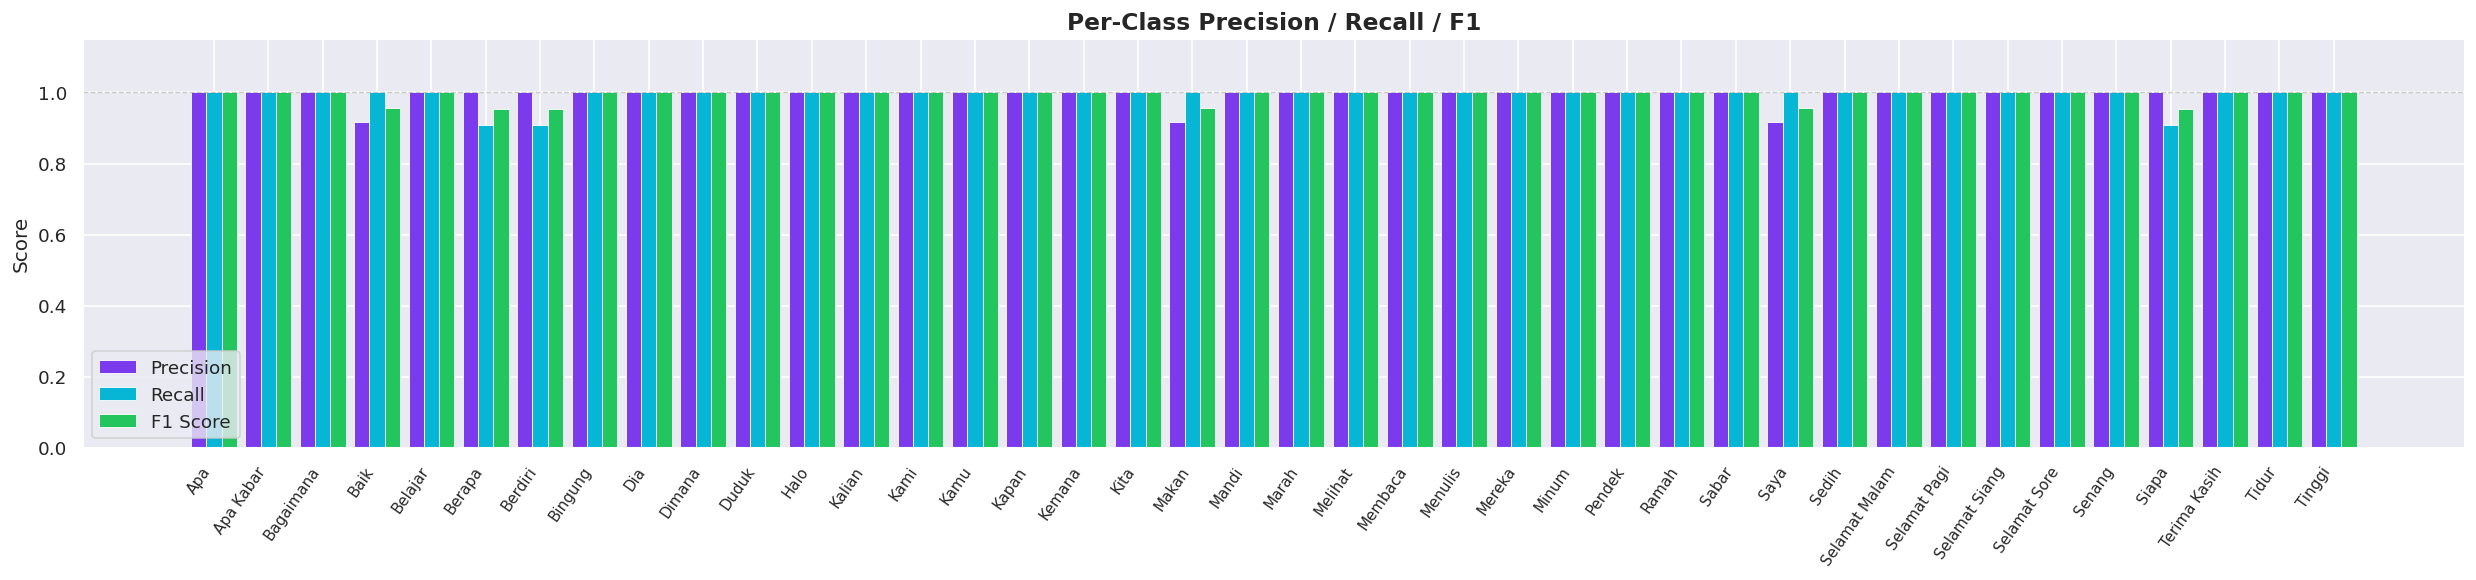

In [47]:
report = classification_report(y_true, y_pred, target_names=actions, output_dict=True)

prec_list = [report[a]['precision'] for a in actions]
rec_list  = [report[a]['recall']    for a in actions]
f1_list   = [report[a]['f1-score']  for a in actions]

x    = np.arange(num_classes)
w    = 0.28

fig, ax = plt.subplots(figsize=(max(14, num_classes * 0.52), 5))
ax.bar(x - w, prec_list, w, label='Precision', color=ACCENT,  edgecolor='white', linewidth=0.5)
ax.bar(x,     rec_list,  w, label='Recall',    color=ACCENT2, edgecolor='white', linewidth=0.5)
ax.bar(x + w, f1_list,   w, label='F1 Score',  color=GREEN,   edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(actions, rotation=55, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='grey', lw=0.8, linestyle='--', alpha=0.4)
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()


In [48]:
print(classification_report(y_true, y_pred, target_names=actions))


               precision    recall  f1-score   support

          Apa       1.00      1.00      1.00        11
    Apa Kabar       1.00      1.00      1.00        11
    Bagaimana       1.00      1.00      1.00        11
         Baik       0.92      1.00      0.96        11
      Belajar       1.00      1.00      1.00        11
       Berapa       1.00      0.91      0.95        11
      Berdiri       1.00      0.91      0.95        11
      Bingung       1.00      1.00      1.00        11
          Dia       1.00      1.00      1.00        11
       Dimana       1.00      1.00      1.00        11
        Duduk       1.00      1.00      1.00        11
         Halo       1.00      1.00      1.00        11
       Kalian       1.00      1.00      1.00        11
         Kami       1.00      1.00      1.00        11
         Kamu       1.00      1.00      1.00        11
        Kapan       1.00      1.00      1.00        11
       Kemana       1.00      1.00      1.00        11
         

## 10 · Final Summary

In [49]:
print('=' * 50)
print('         SIGNLINGO GRU – TRAINING SUMMARY')
print('=' * 50)
print(f'  Epochs trained : {len(hist["loss"])}')
print(f'  Best epoch     : {best_epoch}')
print(f'  Test Accuracy  : {test_accuracy * 100:.2f}%')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  Precision      : {prec:.4f}')
print(f'  Recall         : {rec:.4f}')
print(f'  F1 Score       : {f1:.4f}')
print(f'  Model saved    : {MODEL_SAVE_PATH}')
print('=' * 50)


         SIGNLINGO GRU – TRAINING SUMMARY
  Epochs trained : 53
  Best epoch     : 38
  Test Accuracy  : 99.32%
  Test Loss      : 0.0688
  Precision      : 0.9938
  Recall         : 0.9932
  F1 Score       : 0.9932
  Model saved    : signlingo_v2_gru_4.h5
